In [49]:
import pandas as pd

# --- Define your fine-tuned results ---
finetuned_data = {
    "Model": [
        "text-embedding-3-large",
        "mxbai-embed-large-v1",
        "m2-bert-80M-2k-retrieval",
        "gte-large",
        "voyage-3"
    ],
    "tweets_hate_speech_detection": [
        "0.94(0.92)/0.72(0.83)[0.81]",
        "0.92(0.91)/0.69(0.75)[0.74]",
        "0.84(0.85)/0.64(0.58)[0.73]",
        "0.91(0.89)/0.69(0.73)[0.75]",
        "0.88(0.89)/0.73(0.69)[0.74]"
    ],
    "civil_comments": [
        "0.94(0.93)/0.82(0.82)[0.86]",
        "0.92(0.92)/0.8(0.82)[0.77]",
        "0.84(0.85)/0.71(0.69)[0.72]",
        "0.91(0.9)/0.78(0.79)[0.74]",
        "0.88(0.89)/0.74(0.7)[0.77]"
    ],
    "hatemoji": [
        "0.93(0.94)/0.74(0.8)[0.77]",
        "0.92(0.93)/0.58(0.61)[0.75]",
        "0.84(0.85)/0.57(0.61)[0.73]",
        "0.91(0.91)/0.53(0.65)[0.89]",
        "0.88(0.88)/0.56(0.68)[0.86]"
    ],
    "sbic": [
        "0.94(0.93)/0.71(0.71)[0.77]",
        "0.92(0.91)/0.64(0.65)[0.77]",
        "0.83(0.86)/0.66(0.65)[0.72]",
        "0.91(0.87)/0.64(0.64)[0.74]",
        "0.88(0.88)/0.65(0.65)[0.74]"
    ],
    "hatecheck": [
        "0.93(0.95)/0.7(0.8)[0.77]",
        "0.91(0.95)/0.62(0.68)[0.77]",
        "0.83(0.87)/0.57(0.64)[0.72]",
        "0.87(0.95)/0.62(0.7)[0.74]",
        "0.87(0.91)/0.6(0.73)[0.74]" 
    ]
}

# --- Convert to DataFrame ---
finetuned_df = pd.DataFrame(finetuned_data)

# --- Reshape to long format ---
finetuned_long = finetuned_df.melt(id_vars="Model", var_name="Dataset", value_name="Finetuned_Score")

# --- Parser: extract the five metrics ---
def parse_finetuned_cell(cell):
    """
    Parses a string of the form:
    '0.93(0.91)/0.75(0.81)[0.71]' into:
    Jigsaw_Macro, Jigsaw_True, Task_Macro, Task_True, Certified_Macro
    """
    try:
        jigsaw_part, rest = cell.split('/')
        jigsaw_macro = float(jigsaw_part.split('(')[0])
        jigsaw_true = float(jigsaw_part.split('(')[1].rstrip(')'))

        task_part, certified_part = rest.split('[')
        task_macro = float(task_part.split('(')[0])
        task_true = float(task_part.split('(')[1].rstrip(')'))

        certified_macro = float(certified_part.rstrip(']'))
        return pd.Series([jigsaw_macro, jigsaw_true, task_macro, task_true, certified_macro])
    except Exception as e:
        print(f"Error parsing cell: {cell} -> {e}")
        return pd.Series([None] * 5)

# --- Apply parsing function ---
finetuned_long[["Jigsaw_Macro", "Jigsaw_True", "Task_Macro", "Task_True", "Certified_Macro"]] = \
    finetuned_long["Finetuned_Score"].apply(parse_finetuned_cell)

# --- Drop the raw string column ---
finetuned_long.drop(columns="Finetuned_Score", inplace=True)

# `finetuned_long` is now ready for analysis or plotting
finetuned_long.head()

,Model,Dataset,Jigsaw_Macro,Jigsaw_True,Task_Macro,Task_True,Certified_Macro
0,text-embedding-3-large,tweets_hate_speech_detection,0.94,0.92,0.72,0.83,0.81
1,mxbai-embed-large-v1,tweets_hate_speech_detection,0.92,0.91,0.69,0.75,0.74
2,m2-bert-80M-2k-retrieval,tweets_hate_speech_detection,0.84,0.85,0.64,0.58,0.73
3,gte-large,tweets_hate_speech_detection,0.91,0.89,0.69,0.73,0.75
4,voyage-3,tweets_hate_speech_detection,0.88,0.89,0.73,0.69,0.74


In [50]:
# Define baseline macro accuracy per model *per dataset*
# (from the baseline results table in your first message)
baseline_macro_lookup = {
    ("m2-bert-80M-2k-retrieval", "tweets_hate_speech_detection"): 0.7706,
    ("m2-bert-80M-2k-retrieval", "civil_comments"): 0.7264,
    ("m2-bert-80M-2k-retrieval", "hatemoji"): 0.5922,
    ("m2-bert-80M-2k-retrieval", "sbic"): 0.7401,
    ("m2-bert-80M-2k-retrieval", "hatecheck"): 0.6656,
}

# Baseline Jigsaw macro per model (for plotting the star)
baseline_jigsaw_macro = {
    "text-embedding-3-large": 0.94,
    "mxbai-embed-large-v1": 0.92,
    "m2-bert-80M-2k-retrieval": 0.86,
    "gte-large": 0.90,
    "voyage-3": 0.90
}


In [51]:
%load_ext autoreload
%autoreload 2
import sys
import os
import copy
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.utils.plotting_style import set_figure_size

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


['tweets_hate_speech_detection', 'civil_comments', 'hatemoji', 'sbic', 'hatecheck']


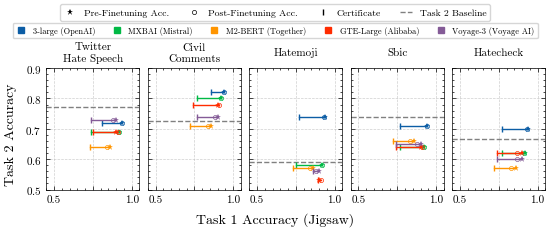

In [52]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

# Apply SciencePlots style
plt.style.use(["science", "no-latex", "scatter"])

# Use the cleaned finetuned DataFrame
models = finetuned_long["Model"].unique()
datasets = list(finetuned_long["Dataset"].unique())  # order preserved
print(datasets)

titles = {
    "tweets_hate_speech_detection": "Twitter\nHate Speech",
    "civil_comments": "Civil\nComments",
    "hatemoji": "Hatemoji",
    "sbic": "Sbic",
    "hatecheck": "Hatecheck",
}

# Provide Jigsaw baseline macro accuracy separately for plotting stars
baseline_jigsaw_macro = {
    "text-embedding-3-large": 0.94,
    "mxbai-embed-large-v1": 0.92,
    "m2-bert-80M-2k-retrieval": 0.86,
    "gte-large": 0.90,
    "voyage-3": 0.90,
}

# Plot for each dataset
fig, axs = plt.subplots(1, len(datasets), sharey=True, layout="constrained", gridspec_kw={"hspace": 0.0})

for i, dataset in enumerate(datasets):
    ax = axs[i]

    # Compute average baseline macro accuracy on this task
    macro_scores = [
        baseline_macro_lookup[(model, dataset)] for model in models if (model, dataset) in baseline_macro_lookup
    ]
    avg_baseline_macro = np.mean(macro_scores)
    # ax.axhline(avg_baseline_macro, linestyle='--', color='red',
    #   label='Avg Baseline Acc. (Task 2)')
    min_baseline_macro = np.min(macro_scores)
    ax.axhline(min_baseline_macro, linestyle="--", color="gray", label="Min Baseline Acc. (Task 2)")

    for j, model in enumerate(models):
        color = f"C{j}"
        row = finetuned_long[(finetuned_long["Model"] == model) & (finetuned_long["Dataset"] == dataset)]

        row = row.iloc[0]
        baseline_macro = baseline_jigsaw_macro[model]

        # Line connecting baseline, finetuned, certified
        x_vals = [baseline_macro, row["Jigsaw_Macro"], row["Certified_Macro"]]
        y_vals = [row["Task_Macro"]] * 3
        ax.plot(x_vals, y_vals, color=color, linestyle="-", marker="none")

        # Markers
        # ax.scatter(baseline_macro, row["Task_Macro"], color=color, marker="*", s=2)  # baseline
        # ax.scatter(row["Jigsaw_Macro"], row["Task_Macro"], color=color, facecolors="none", marker="o", s=2)  # finetuned
        # ax.scatter(row["Certified_Macro"], row["Task_Macro"], edgecolors=color, marker="o", s=2)  # certified
        ax.plot(
            row["Jigsaw_Macro"],
            row["Task_Macro"],
            color=color,
            marker="o",
            markersize=3,
            markeredgewidth=0.5,
            markerfacecolor="none",
        )  # finetuned
        ax.plot(
            baseline_macro,
            row["Task_Macro"],
            color=color,
            marker="*",
            markersize=5,
            markeredgewidth=0.0,
        )  # baseline
        ax.plot(
            row["Certified_Macro"],
            row["Task_Macro"],
            color=color,
            marker="|",
            markersize=5,
            # markerfacecolor="none",
            # markeredgewidth=0.5,
        )  # certified - hollow circle with thinner edge

    # Title and axes
    ax.set_title(titles[dataset], y=1.06, va="center", fontsize=8)
    ax.set_xlim(0.45, 1.05)
    ax.set_xticks([0.5, 0.75, 1.0], labels=["0.5", "", "1.0"])
    ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])
    # ax.set_ylim(0.55, 0.85)
    ax.grid(True, linestyle="--", alpha=0.6)

import matplotlib.lines as mlines

model_names = {
    "text-embedding-3-large": "3-large (OpenAI)",
    "mxbai-embed-large-v1": "MXBAI (Mistral)",
    "m2-bert-80M-2k-retrieval": "M2-BERT (Together)",
    "gte-large": "GTE-Large (Alibaba)",
    "voyage-3": "Voyage-3 (Voyage AI)",
}

# Top row: model-color legend (simplified labels)
model_lines = []
for j, model in enumerate(models):
    color = f"C{j}"
    # Create a legend entry for each model
    model_lines.append(mlines.Line2D([0], [0], color=color, lw=0, marker="s", markersize=5, label=model_names[model]))


# Bottom row: marker types and dashed line
symbol_lines = [
    mlines.Line2D(
        [0],
        [0],
        marker="*",
        lw=0,
        color="black",
        markersize=5,
        markeredgewidth=0.0,
        label="Pre-Finetuning Acc.",
    ),
    mlines.Line2D(
        [0],
        [0],
        marker="o",
        markersize=3,
        lw=0,
        color="black",
        markeredgewidth=0.5,
        markerfacecolor="none",
        label="Post-Finetuning Acc.",
    ),
    mlines.Line2D([0], [0], marker="|", lw=0, color="black", markersize=5, label="Certificate"),
    mlines.Line2D([0], [0], linestyle="--", color="gray", label="Task 2 Baseline"),
]

# Combine both rows
full_legend = model_lines + symbol_lines

legend = fig.legend(
    handles=symbol_lines,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),  # position above the plot
    ncol=4,  # auto-wrap into two rows
    frameon=True,  # outline box
    handlelength=1.2,
    fontsize=7,
)

legend = fig.legend(
    handles=model_lines,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),  # position above the plot
    ncol=5,  # auto-wrap into two rows
    frameon=True,  # outline box
    fontsize=6,
    handlelength=1.2
)

fig.supxlabel("Task 1 Accuracy (Jigsaw)", fontsize=10)
fig.supylabel("Task 2 Accuracy", fontsize=10)

# Legend: only one color entry per model
# custom_lines = [plt.Line2D([0], [0], color=model_colors[m], lw=4) for m in models]
# ax.legend(custom_lines, models, title="Model", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)

set_figure_size(fig, fraction=1.0, subplots=(1, len(datasets)), dpi=300, shrink_height=1.3, portrait=True)
plt.savefig("figures/finetuned_results.pdf", dpi=300)